<a href="https://colab.research.google.com/github/miller00315/-genetic_algorithms_studies/blob/main/data_wrangling_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dados_wdi = pd.read_excel('(2.2) WDI World Bank.xlsx', na_values='..')
dados_grupo = pd.read_excel('(2.3) WDI Income Group.xlsx')
dados_paises = pd.read_excel('(2.4) WDI Country.xlsx')

In [3]:
dados_wdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383577 entries, 0 to 383576
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Country Name   383574 non-null  object 
 1   Country Code   383572 non-null  object 
 2   Series Name    383572 non-null  object 
 3   Series Code    383572 non-null  object 
 4   2021 [YR2021]  108687 non-null  float64
 5   Topic          383572 non-null  object 
dtypes: float64(1), object(5)
memory usage: 17.6+ MB


In [4]:
dados_wdi['Country Name'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
       'Faroe Islands',

In [5]:
dados_wdi['Country Name'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
       'Faroe Islands',

In [6]:
dados_wdi['Country Name'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
       'Faroe Islands',

In [7]:
dados_wdi.rename(columns={'Country Name':'pais',
                          'Country Code':'cod_pais',
                          'Series Name': 'serie',
                          'Series Code': 'cod_serie',
                          '2021 [YR2021]': 'ano_2021',
                          'Topic': 'topico'}, inplace=True)


In [8]:
dados_wdi['pais'].tail(n=20)

,pais
383557,World
383558,World
383559,World
383560,World
383561,World
383562,World
383563,World
383564,World
383565,World
383566,World


In [9]:
dados_wdi = dados_wdi.iloc[0:383572,]

In [10]:
dados_wdi['pais'].tail(n=20)

,pais
383552,World
383553,World
383554,World
383555,World
383556,World
383557,World
383558,World
383559,World
383560,World
383561,World


In [11]:
dados_saude = dados_wdi[dados_wdi['topico'].str.startswith('Health')]

In [12]:
dados_saude = pd.pivot(dados_saude,
                       index=['pais','cod_pais'],
                       columns=['serie'],
                       values='ano_2021')

In [14]:
dados_saude.reset_index(inplace=True)

In [15]:
dados_paises.rename(columns={'Country':'cod_pais'},
                    inplace=True)

In [17]:
dados_saude = pd.merge(dados_saude, dados_paises,
                       how='left',
                       on='cod_pais')

In [19]:
dados_saude = dados_saude[~ dados_saude['Name'].isna()].reset_index(drop=True)

In [20]:
dados_saude.drop(columns=['Name'], inplace=True)

In [21]:
dados_saude.dropna(axis=1, how='all', inplace=True)

In [22]:
dados_grupo_select = dados_grupo[['Code', 'Income Group']].copy()


In [23]:
dados_grupo_select.rename(columns={'Code':'cod_pais'},
                          inplace=True)

In [24]:
dados_saude = pd.merge(dados_saude, dados_grupo_select,
                       how='left',
                       on='cod_pais')

In [25]:
organizar = dados_saude.pop('Income Group')

In [26]:
dados_saude.insert(2, 'Group', organizar)

In [27]:
col_pos = dados_saude.columns

In [28]:
dados_saude.iloc[:,23].describe()

,Diabetes prevalence (% of population ages 20 to 79)
count,212.000000
mean,9.014623
std,5.305360
min,1.100000
25%,5.600000
50%,7.400000
75%,11.150000
max,30.800000


In [29]:
estat_grupo = dados_saude.iloc[:,[2,23]].groupby('Group').mean().reset_index()


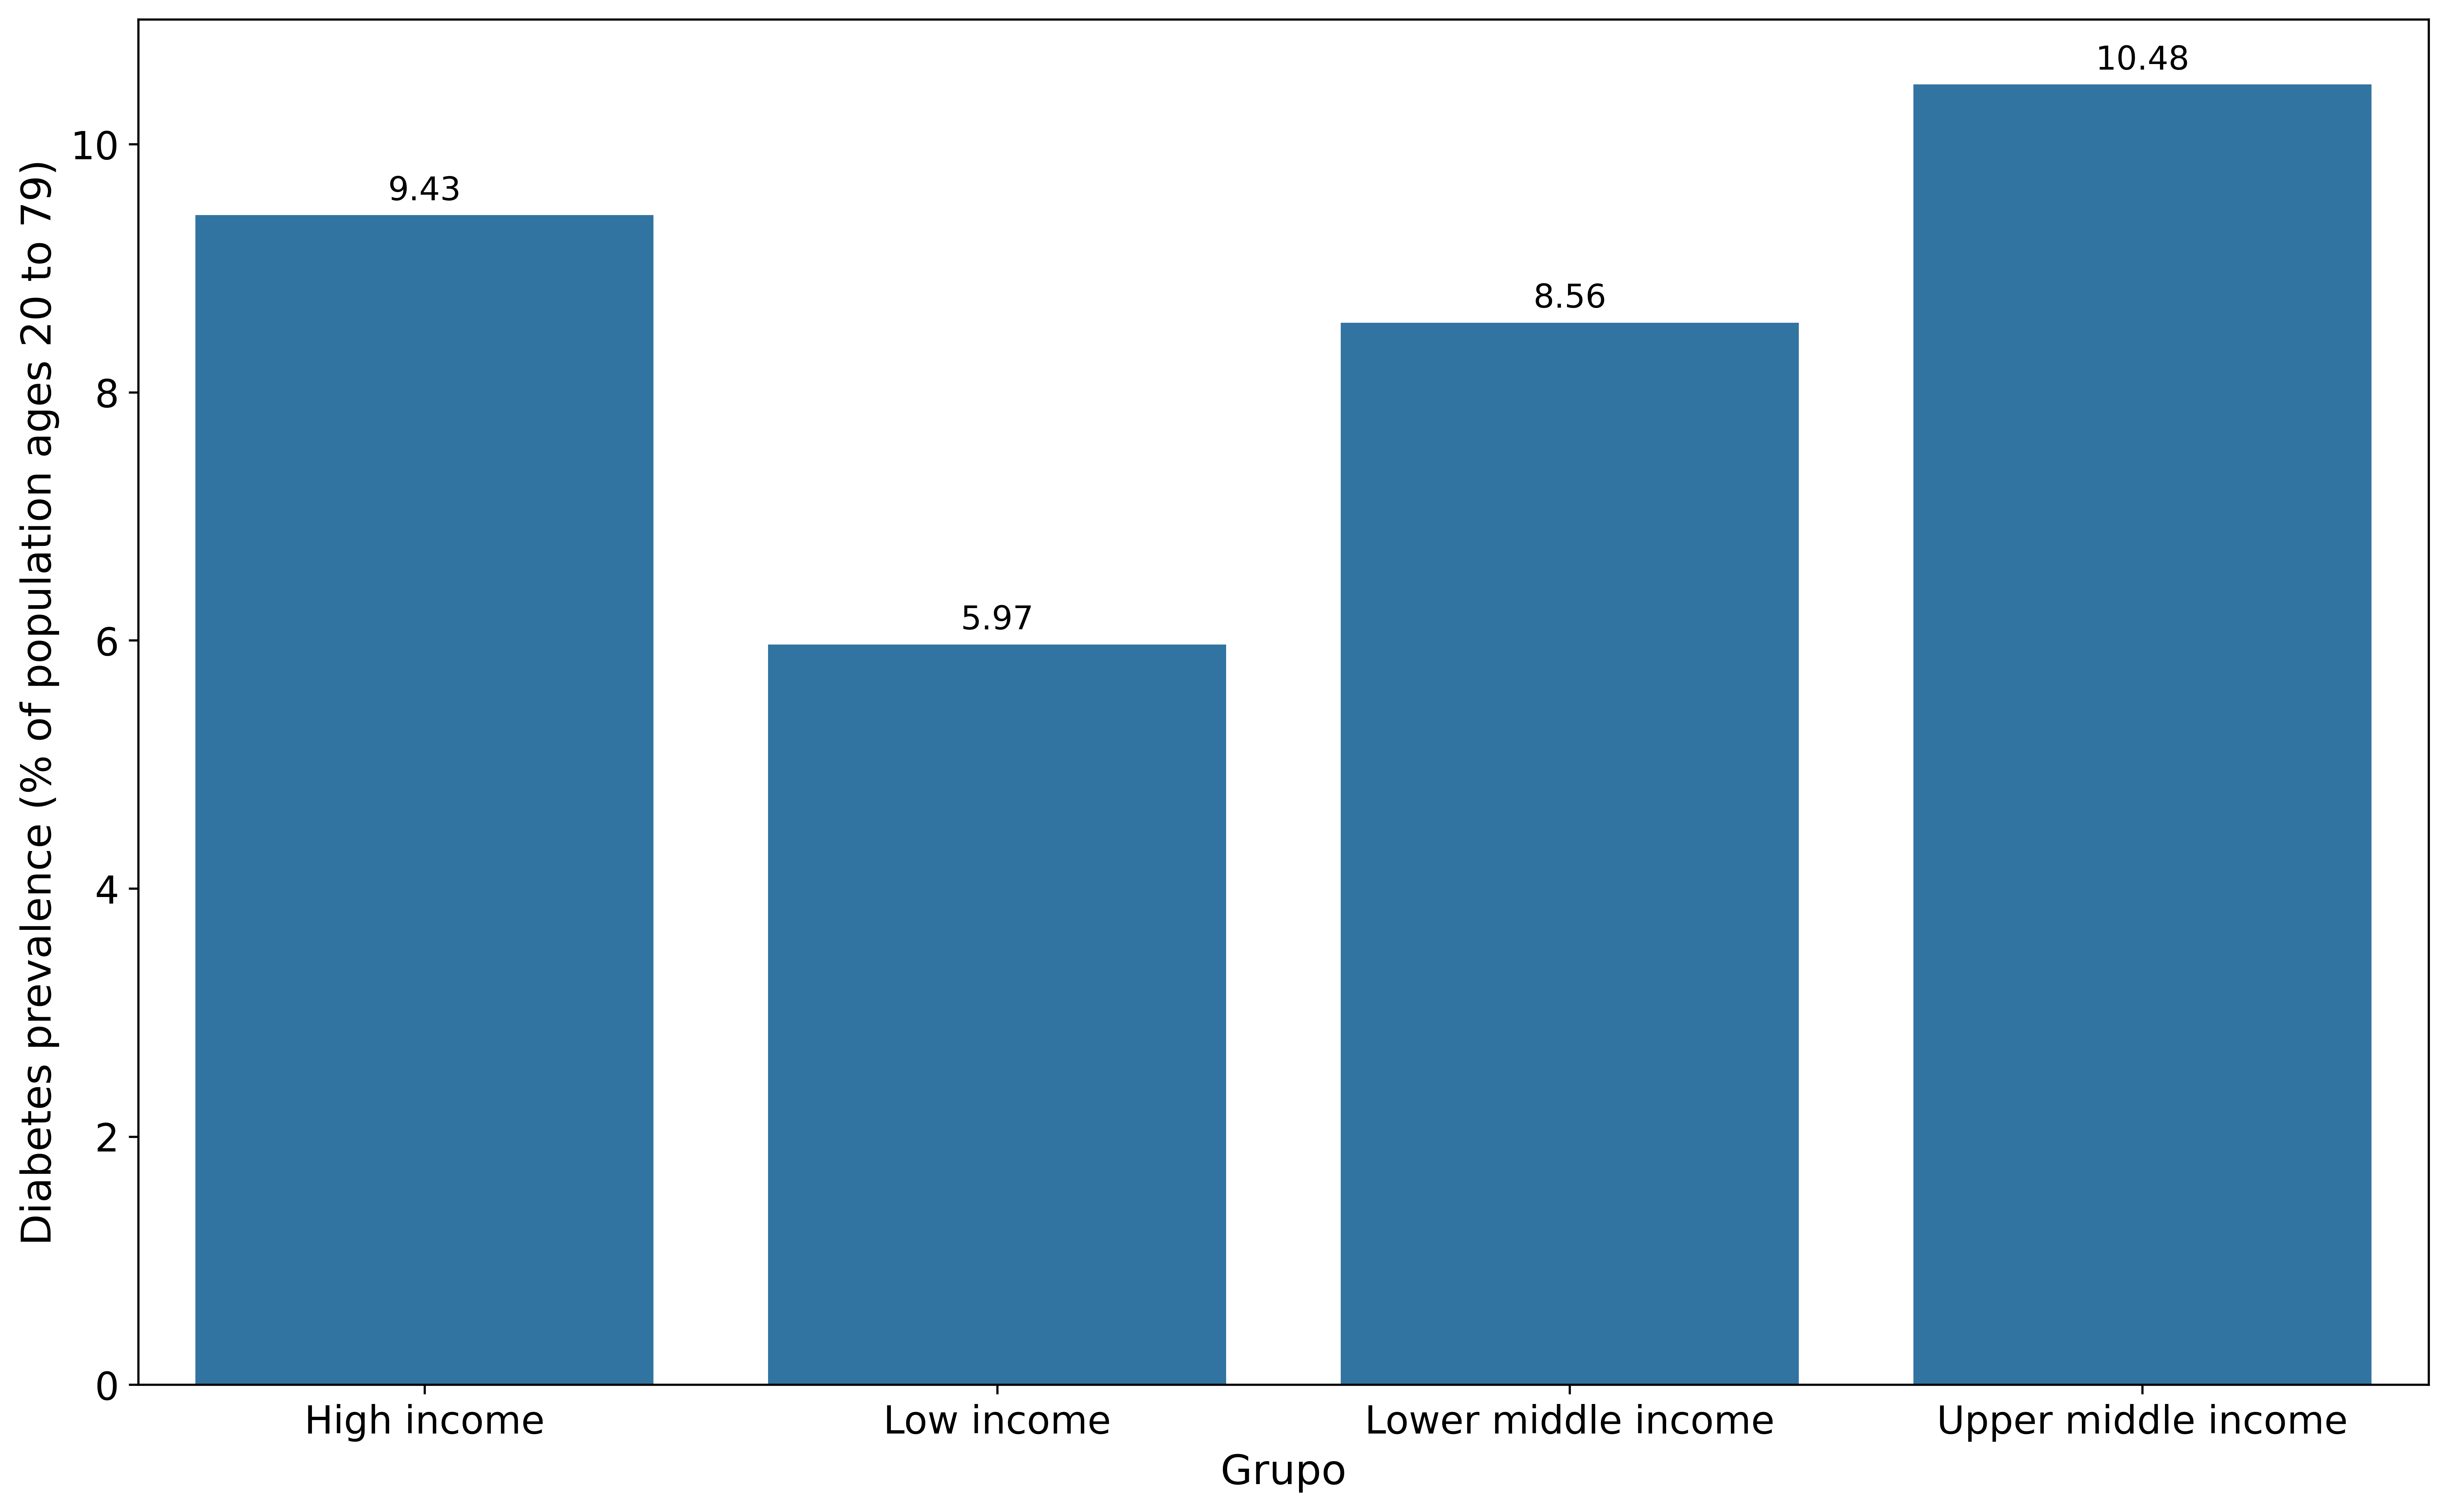

In [30]:
plt.figure(figsize=(15,9), dpi = 600)
ax = sns.barplot(data=estat_grupo, x=estat_grupo.iloc[:,0], y=estat_grupo.iloc[:,1])
for container in ax.containers: ax.bar_label(container, fmt='%.2f', padding=3, fontsize=12)
plt.xlabel('Grupo',fontsize=15)
plt.ylabel('Diabetes prevalence (% of population ages 20 to 79)', fontsize=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
